# Multiple Choice Question Evaluation for Zeolite Synthesis

Run with kernel v6 instead of v7

This notebook evaluates an LLM's performance on multiple-choice questions about zeolite synthesis by comparing generated answers with ground truth.

In [1]:
# Core imports
import os
import torch
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm

# LangChain and Transformers
from langchain.prompts import ChatPromptTemplate
from langchain.llms import HuggingFacePipeline
from langchain.chains import LLMChain
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# GPU setup
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
torch.cuda.set_device(0)

In [2]:
!nvidia-smi

Mon Feb 16 13:02:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   40C    P0             67W /  230W |       4MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!kill -9 2851800 

/bin/bash: line 0: kill: (2851800) - No such process


In [4]:
# Initialize the model
model_name = "mistralai/Mistral-7B-Instruct-v0.1"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(
    model_name, 
    trust_remote_code=True, 
    use_fast=False
)

model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    device_map="auto", 
    trust_remote_code=True,
    torch_dtype=torch.float16
)

# Set up pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_length=2000)
llm = HuggingFacePipeline(pipeline=pipe)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_554708/3692147747.py:20: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


In [5]:
# Multiple choice prompt template
MC_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
{context}

Question: {question}

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E."""

In [6]:
def evaluate_mc_response(query, correct_answer, context):
    """Evaluate a single multiple choice question."""
    mc_prompt = ChatPromptTemplate.from_template(MC_PROMPT)
    chain = LLMChain(llm=llm, prompt=mc_prompt)
    
    try:
        # Get model's answer
        full_response = chain.run(context=context, question=query)
        
        # Debug print
        print(f"Raw response: '{full_response}'")
        
        # Find the last occurrence of "Answer: " (to avoid the example)
        last_answer_pos = full_response.rfind("Answer: ")
        
        if last_answer_pos != -1:
            # Get the character right after "Answer: "
            model_answer = full_response[last_answer_pos + 8].upper()
            
            if model_answer in ['A', 'B', 'C', 'D', 'E']:
                # Try to get explanation if available
                explanation = ""
                answer_end = full_response[last_answer_pos:].split('\n')[0]  # Get just the answer line
                if '-' in answer_end:
                    explanation = answer_end.split('-', 1)[1].strip()
                
                return {
                    'query': query,
                    'context': context,
                    'model_answer': model_answer,
                    'correct_answer': correct_answer,
                    'is_correct': model_answer == correct_answer,
                    'full_response': full_response,
                    'explanation': explanation
                }
        
        # If we get here, no valid answer was found
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'context': context,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

In [7]:
# Main evaluation
# Read ONLY from the manually verified question bank (both sheets)
excel_file = 'QuestionBank31Oct_Ericonly.xlsx'

# Read only Synthesis and Chem Con & Catalysis sheets (manually verified)
sheets_to_use = ['Synthesis', 'Chem Con & Catalysis']
all_dfs = []

for sheet_name in sheets_to_use:
    df = pd.read_excel(excel_file, sheet_name=sheet_name)
    df['source_sheet'] = sheet_name  # Track which sheet each question came from
    all_dfs.append(df)
    print(f"Loaded {len(df)} questions from sheet: '{sheet_name}'")

# Combine both sheets into one dataframe
synthesis_df = pd.concat(all_dfs, ignore_index=True)

# Remove rows with blank questions
synthesis_df = synthesis_df.dropna(subset=['gpt_generated_question'])

print(f"\nTotal questions from manually verified sheets: {len(synthesis_df)}")
print(f"Questions per sheet:")
for sheet in synthesis_df['source_sheet'].unique():
    count = len(synthesis_df[synthesis_df['source_sheet'] == sheet])
    print(f"  {sheet}: {count}")

# Process each question
results = []
correct_count = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating questions"):
    context = row['abstract']
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Evaluate the question
    result = evaluate_mc_response(question, correct_answer, context)
    results.append(result)
    
    # Update count and show progress
    if result['is_correct']:
        correct_count += 1
    
    # Show immediate feedback
    print(f"\nQuestion {idx + 1}:")
    print(f"Model's answer: {result['model_answer']}")
    if 'explanation' in result:
        print(f"Explanation: {result['explanation']}")
    print(f"Correct answer: {correct_answer}")
    print(f"Current accuracy: {(correct_count / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
final_accuracy = (correct_count / len(synthesis_df)) * 100

# Print summary
print("\n=== Final Results ===")
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count}")
print(f"Final accuracy: {final_accuracy:.2f}%")

# Save detailed results
output_filename = f"mc_evaluation_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(output_filename, 'w') as f:
    json.dump({
        'summary': {
            'total_questions': len(synthesis_df),
            'correct_answers': correct_count,
            'accuracy': final_accuracy
        },
        'detailed_results': results
    }, f, indent=2)

print(f"\nDetailed results saved to: {output_filename}")

Loaded 23 questions from sheet: 'Synthesis'
Loaded 20 questions from sheet: 'Chem Con & Catalysis'

Total questions from manually verified sheets: 43
Questions per sheet:
  Synthesis: 23
  Chem Con & Catalysis: 20


Evaluating questions:   0%|          | 0/43 [00:00<?, ?it/s]/tmp/ipykernel_554708/4103750729.py:4: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=llm, prompt=mc_prompt)
/tmp/ipykernel_554708/4103750729.py:8: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  full_response = chain.run(context=context, question=query)
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/tmp/ipykernel_554708/4103750729.py:4: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=llm, prompt=mc_prompt)
/tmp/ipykernel_554708/4103750729.py:8: LangChainDeprecationWarning: The method `Chain.run` was deprecated in la

Evaluating questions:   2%|▏         | 1/43 [00:05<03:46,  5.40s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Two-layered H-ZSM-5-mordenite membranes have been prepared on alumina tubular supports. The objective of this work is to merge the catalytic activity of H-ZSM-5 with the pervaporation water selectivity of mordenite membranes, i.e. to produce true bi-functional zeolite membranes. To be sure that the needed thermal treatment (to remove TPAOH template from the H-ZSM-5 pores) stage did not alter the hydrophilic character of these two-layered H-ZSM-5-mordenite membranes, the calcination was carried out under a steam/air atmosphere. Experiments concerning the pervaporation of water/ethanol mixtures and the esterification of acetic acid with ethanol were performed to demonstrate the applicability of the membranes prepared here.

Question: What is t

Evaluating questions:   5%|▍         | 2/43 [00:06<02:09,  3.16s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The reduction of NO by hydrocarbons such as C2H4, C2H6, C3H6, and C3H8 has been investigated over mordenite-type zeolite catalysts including HM, CuHM, NZA (natural zeolite), and CuNZA prepared by an ion-exchange method in a continuous flow fixed-bed reactor. NO conversion over CuNZA catalyst reaches about 94% with 2000 ppm of C3H6 at 500¬∞C. As reductants, alkenes seem to exhibit a higher performance for NO conversion than alkanes regardless of the catalysts. No deterioration of the catalytic activity due to carbonaceous deposits for CuNZA was observed above 400¬∞C even after 30 h of on-stream time, but SO2 in the feed gas stream causes a severe poisoning of the CuNZA catalyst. The effect of H2O on NO conversion was significant regardless of

Evaluating questions:  98%|█████████▊| 42/43 [02:02<00:01,  1.33s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The mono(m-oxo) dicopper cores present in the pores of Cu-ZSM-5 are active for the partial oxidation of methane to methanol. However, copper on the external surface reduces the ratio of active, selective sites to unselective sites. More efficient catalysts are obtained by controlling the copper deposition during synthesis. Herein, the external exchange sites of ZSM-5 samples were passivated by bis(trimethylsilyl) trifluoroacetamide (BSTFA) followed by calcination, promoting selective deposition of intraporous copper during aqueous copper ion exchange. At an optimum level of 1-2 wt % SiO2, IR studies showed a 64 % relative reduction in external copper species and temperature-programmed oxidation analysis showed an associated increase in the f

Evaluating questions: 100%|██████████| 43/43 [02:05<00:00,  2.92s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Continuous flows of a standard reactant mixture, featuring 0.6% nitric oxide, 0.6% ammonia and 3.3% oxygen at moderate space velocities over 4 different catalysts, have been used to compare relative activities for selective catalytic reduction of NOx at 373‚Äì773 K. The catalysts tested were: Cu-ZSM-5 featuring > 100% ion-exchange; a conventionally prepared vanadia-titania-tungstate (VTT) material and two unconventional catalysts prepared by vanadia deposition onto ex-sol-gel WO3TiO2 supports. At catalytic temperature 473 K, higher conversion to N2 was achieved over Cu-ZSM-5 than over the other three materials. Tests without NO at 473 K showed insignificant contributions to N2 formation from ammonia oxidation over any of the catalysts, where

# Comparative Evaluation: Different Context Sources

Now we'll compare the LLM's accuracy across different context retrieval methods:
1. **Abstract as context** (baseline - already computed above)
2. **No context** - Pure LLM knowledge
3. **FAISS only** - Semantic similarity search (k=10)
4. **MMR only** - Maximum Marginal Relevance search (k=10)
5. **BM25 only** - Keyword-based retrieval (k=10)
6. **Hybrid (MMR + BM25)** - Combined retrieval (k=10)
7. **LLM-Optimized Query** - Query optimization + FAISS retrieval (k=10)

In [8]:
# Load the vector database and retrieval components from Mrigi 21
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.vectorstores import FAISS
from langchain.retrievers import BM25Retriever
from pathlib import Path

# Initialize embeddings (same as Mrigi 21)
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")

# Load FAISS index
INDEX_DIRECTORY = Path("faiss_index")
INDEX_NAME = "index"

if not INDEX_DIRECTORY.exists():
    raise FileNotFoundError(f"Vector index directory '{INDEX_DIRECTORY}' not found.")

vector_db = FAISS.load_local(
    INDEX_DIRECTORY,
    embeddings,
    index_name=INDEX_NAME,
    allow_dangerous_deserialization=True
)
print(f"✓ Loaded vector database from {INDEX_DIRECTORY} with {vector_db.index.ntotal} vectors")

# Get all documents for BM25
all_docs = vector_db.similarity_search("", k=vector_db.index.ntotal)
bm25_retriever = BM25Retriever.from_documents(all_docs)
bm25_retriever.k = 10
print(f"✓ Initialized BM25 retriever with {len(all_docs)} documents")

/tmp/ipykernel_554708/2636707329.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")


✓ Loaded vector database from faiss_index with 1474439 vectors
✓ Initialized BM25 retriever with 1474439 documents
✓ Initialized BM25 retriever with 1474439 documents


In [9]:
# Define hybrid search function (from Mrigi 21)
def hybrid_search(query, vector_db, bm25_retriever, k_total=10, k_bm25=10, k_mmr=10, 
                  mmr_fetch_k=40, mmr_lambda=0.6):
    """
    Hybrid retrieval combining BM25 and MMR results.
    
    Args:
        query: Search query string
        vector_db: FAISS vector store
        bm25_retriever: BM25 retriever instance
        k_total: Total number of documents to return (default=10)
        k_bm25: Number of documents to retrieve from BM25 (default=10)
        k_mmr: Number of documents to retrieve from MMR (default=10)
        mmr_fetch_k: Candidate pool size for MMR (default=40)
        mmr_lambda: Diversity parameter for MMR (default=0.6)
    
    Returns:
        List of unique documents
    """
    # Get BM25 results
    bm25_retriever.k = k_bm25
    bm25_docs = bm25_retriever.get_relevant_documents(query)
    
    # Get MMR results
    mmr_docs = vector_db.max_marginal_relevance_search(
        query,
        k=k_mmr,
        fetch_k=mmr_fetch_k,
        lambda_mult=mmr_lambda
    )
    
    # Combine and deduplicate
    seen_content = set()
    combined_docs = []
    
    for doc in bm25_docs + mmr_docs:
        content_hash = hash(doc.page_content)
        if content_hash not in seen_content:
            seen_content.add(content_hash)
            combined_docs.append(doc)
            if len(combined_docs) >= k_total:
                break
    
    return combined_docs

print("✓ Hybrid search function defined")

✓ Hybrid search function defined


In [10]:
# Define LLM query optimizer function (adapted from Mrigi 21 for MCQ context)
def optimize_query_for_mcq(question: str, llm) -> str:
    """
    Use LLM to convert a multiple choice question into an optimized search query.
    
    Args:
        question: Original MCQ question (with options A-E)
        llm: LangChain LLM instance
    
    Returns:
        Optimized search query string
    """
    QUERY_OPTIMIZER_PROMPT = """You are helping optimize multiple choice questions for academic literature search.
Given a multiple choice question about zeolite synthesis, extract the core scientific concepts and convert it into a concise keyword-based search query.
Focus on the main topic: materials, synthesis methods, characterization techniques, properties, or conditions being asked about.
Remove question phrasing, multiple choice options (A-E), and filler words.
Preserve chemical formulas, abbreviations, and domain-specific terminology.
Output a single line of lowercase keywords in a natural but compact order.
Do not explain or summarize—only output the optimized search query.

Question: {question}

Optimized query:"""
    
    try:
        # Create a simple prompt
        prompt_template = ChatPromptTemplate.from_template(QUERY_OPTIMIZER_PROMPT)
        chain = LLMChain(llm=llm, prompt=prompt_template)
        
        # Generate optimized query
        response = chain.run(question=question)
        
        # Extract only the generated part (after the prompt)
        if "Optimized query:" in response:
            optimized_query = response.split("Optimized query:")[-1].strip()
        else:
            optimized_query = response.strip()
        
        # Clean up any extra text after the first line
        optimized_query = optimized_query.split('\n')[0].strip()
        
        return optimized_query if optimized_query else question  # Fallback to original if empty
    except Exception as e:
        print(f"Error optimizing query: {e}")
        return question  # Fallback to original question on error

print("✓ Query optimizer function defined for MCQ context")

✓ Query optimizer function defined for MCQ context


## Evaluation 1: No Context (Pure LLM Knowledge)

In [11]:
# No context prompt template
NO_CONTEXT_PROMPT = """
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer.

Question: {question}

Provide your answer in the following format EXACTLY:
Answer: [LETTER] - [One sentence explanation]

For example:
Answer: B - The synthesis temperature was increased to improve crystallization.

Choose only from options A, B, C, D, or E."""

def evaluate_mc_no_context(query, correct_answer):
    """Evaluate a single multiple choice question WITHOUT context."""
    no_context_prompt = ChatPromptTemplate.from_template(NO_CONTEXT_PROMPT)
    chain = LLMChain(llm=llm, prompt=no_context_prompt)
    
    try:
        # Get model's answer
        full_response = chain.run(question=query)
        
        # Find the last occurrence of "Answer: "
        last_answer_pos = full_response.rfind("Answer: ")
        
        if last_answer_pos != -1:
            model_answer = full_response[last_answer_pos + 8].upper()
            
            if model_answer in ['A', 'B', 'C', 'D', 'E']:
                explanation = ""
                answer_end = full_response[last_answer_pos:].split('\n')[0]
                if '-' in answer_end:
                    explanation = answer_end.split('-', 1)[1].strip()
                
                return {
                    'query': query,
                    'model_answer': model_answer,
                    'correct_answer': correct_answer,
                    'is_correct': model_answer == correct_answer,
                    'full_response': full_response,
                    'explanation': explanation
                }
        
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"No valid answer found in response"
        }
        
    except Exception as e:
        print(f"Processing error: {str(e)}")
        return {
            'query': query,
            'model_answer': 'INVALID',
            'correct_answer': correct_answer,
            'is_correct': False,
            'error': f"Error processing response: {str(e)}"
        }

print("✓ No-context evaluation function defined")

✓ No-context evaluation function defined


In [12]:
# Run evaluation with NO CONTEXT
print("="*80)
print("EVALUATION 1: NO CONTEXT (Pure LLM Knowledge)")
print("="*80)

results_no_context = []
correct_count_no_context = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (No Context)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    result = evaluate_mc_no_context(question, correct_answer)
    results_no_context.append(result)
    
    if result['is_correct']:
        correct_count_no_context += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_no_context / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_no_context = (correct_count_no_context / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - NO CONTEXT")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_no_context}")
print(f"Accuracy: {accuracy_no_context:.2f}%")
print("="*80)

EVALUATION 1: NO CONTEXT (Pure LLM Knowledge)


Evaluating (No Context):   0%|          | 0/43 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):   2%|▏         | 1/43 [00:04<02:53,  4.14s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize ef


Progress: 10/43 questions
Current accuracy: 50.00%


Evaluating (No Context):  26%|██▌       | 11/43 [01:16<09:51, 18.47s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  28%|██▊       | 12/43 [01:17<06:48, 13.17s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m


Progress: 20/43 questions
Current accuracy: 50.00%


...


Progress: 30/43 questions
Current accuracy: 43.33%


Evaluating (No Context):  72%|███████▏  | 31/43 [01:57<00:22,  1.89s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  74%|███████▍  | 32/43 [02:01<00:28,  2.57s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m


Progress: 40/43 questions
Current accuracy: 45.00%


Evaluating (No Context):  95%|█████████▌| 41/43 [03:17<00:10,  5.03s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (No Context):  98%|█████████▊| 42/43 [03:18<00:03,  3.78s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to m


RESULTS - NO CONTEXT
Total questions: 43
Correct answers: 20
Accuracy: 46.51%


## Evaluation 2: FAISS Only (Semantic Similarity, k=10)

In [13]:
# Run evaluation with FAISS retrieval
print("="*80)
print("EVALUATION 2: FAISS ONLY (Semantic Similarity, k=10)")
print("="*80)

results_faiss = []
correct_count_faiss = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (FAISS)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using FAISS
    retrieved_docs = vector_db.similarity_search(question, k=10)
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_faiss.append(result)
    
    if result['is_correct']:
        correct_count_faiss += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_faiss / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_faiss = (correct_count_faiss / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - FAISS ONLY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_faiss}")
print(f"Accuracy: {accuracy_faiss:.2f}%")
print("="*80)

EVALUATION 2: FAISS ONLY (Semantic Similarity, k=10)


Evaluating (FAISS):   0%|          | 0/43 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2269, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In this work, two-layered mordenite-ZSM-5 bi-functional membranes have been prepared by a two-step hydrothermal procedure on tubular supports. Due to its lower content in aluminum and hence higher stability under acidic conditions, mordenite would be preferred to zeolite A as the hydrophilic layer in a two-layered zeolite membrane and therefore the membranes studied in this work combine a catalytic H-ZSM-5 layer and a mordenite separation layer prepared in a two-step preparation procedure. Given the harsh conditions used in hydrothermal synthesis of zeolites, an important concern is the integrity of the first membrane (H-ZSM-5) during synthesis of the second layer, an aspect that has been addressed in this work.

This information is from DOI

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2448, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2448, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (FAISS):   5%|▍         | 2/43 [00:02<00:47,  1.

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
More attractive strategies are based on the so-called dual templating approaches, which involve the use of a mixture of a micro-template (i.e. a conventional SDA used for the crystallization of zeolites) and a meso-template able to generate the mesoporous structure. Meso-templates, in turn, are defined soft or hard when they are constituted, respectively, by organized systems of molecules (micelles, polymers) or solid particles of different nature (e.g. carbon particles, nanotubes, etc.).

This information is from DOI: 10.1039/c2cy20510f

During zeolite synthesis, an SDA as well as a mesoporogen can be added. In this case, one can category this method as a dual-template method. The SDA is responsible for the formation of micropores in the ze

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The reduction of NO by hydrocarbons such as C2H4, C2H6, C3H6, and C3H8 has been investigated over mordenite-type zeolite catalysts including HM, CuHM, NZA (natural zeolite), and CuNZA prepared by an ion-exchange method in a continuous flow fixed-bed reactor. NO conversion over CuNZA catalyst reaches about 94% with 2000 ppm of C3H6 at 500°C. As reductants, alkenes seem to exhibit a higher performance for NO conversion than alkanes regardless of the catalysts. No deterioration of the catalytic activity due to carbonaceous deposits for CuNZA was observed above 400°C even after 30 h of on-stream time, but SO2 in the feed gas stream causes a severe poisoning of the CuNZA catalyst. The effect of H2O on NO conversion was significant regardless of t

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2151, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (FAISS):  98%|█████████▊| 42/43 [01:29<00:01,  2.00s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
This work helps to clarify the catalytic role of various acid sites on ZSM-5 as well as the nature of active Cu species in the carbonylation reaction, which is of great benefit to the design of efficient zeolite catalysts for the carbonylation process.

This information is from DOI: 10.1039/c8cy00296g

In 1986, Iwamoto et al. discovered the remarkable activity of Cu-ZSM-5 catalysts in NO decomposition. After that, significant efforts have been devoted to understand why this system is unique in comparison with other copper-containing systems or transition metal ions exchanged in ZSM-5. Compared to other previously studied zeolite materials, the over-exchanged Cu-ZSM-5 exhibits a significant enhancement both in terms of the conversion rate and

Evaluating (FAISS): 100%|██████████| 43/43 [01:41<00:00,  2.36s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Since Iwamoto and Held et al. reported that the selective catalytic reduction (SCR) of NOx by hydrocarbon over Cu/ZSM-5 proceeded even in a large excess oxygen, many researchers in the world have enthusiastically tried to find a catalyst with better activity. Though Cu/ZSM-5 is known to show a good activity, it is still not high enough to fulfill further stringent emission standards. Therefore, the understanding of the reaction mechanism is essential for the design of better catalysts.

This information is from DOI: 10.1016/s0920-5861(98)00172-2

Since Iwamoto and Held et al. reported that the selective catalytic reduction (SCR) of NOx by hydrocarbon over Cu/ZSM-5 proceeded even in a large excess oxygen, many researchers in the world have en

## Evaluation 3: MMR Only (Maximum Marginal Relevance, k=10)

In [14]:
# Run evaluation with MMR retrieval
print("="*80)
print("EVALUATION 3: MMR ONLY (Maximum Marginal Relevance, k=10)")
print("="*80)

results_mmr = []
correct_count_mmr = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (MMR)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using MMR
    retrieved_docs = vector_db.max_marginal_relevance_search(
        question,
        k=10,
        fetch_k=40,
        lambda_mult=0.6
    )
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_mmr.append(result)
    
    if result['is_correct']:
        correct_count_mmr += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_mmr / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_mmr = (correct_count_mmr / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - MMR ONLY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_mmr}")
print(f"Accuracy: {accuracy_mmr:.2f}%")
print("="*80)

EVALUATION 3: MMR ONLY (Maximum Marginal Relevance, k=10)


Evaluating (MMR):   0%|          | 0/43 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2063, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.


Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In this work, two-layered mordenite-ZSM-5 bi-functional membranes have been prepared by a two-step hydrothermal procedure on tubular supports. Due to its lower content in aluminum and hence higher stability under acidic conditions, mordenite would be preferred to zeolite A as the hydrophilic layer in a two-layered zeolite membrane and therefore the membranes studied in this work combine a catalytic H-ZSM-5 layer and a mordenite separation layer prepared in a two-step preparation procedure. Given the harsh conditions used in hydrothermal synthesis of zeolites, an important concern is the integrity of the first membrane (H-ZSM-5) during synthesis of the second layer, an aspect that has been addressed in this work.

This information is from DOI

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2257, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (MMR):   5%|▍         | 2/43 [00:02<00:42,  1.05s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
More attractive strategies are based on the so-called dual templating approaches, which involve the use of a mixture of a micro-template (i.e. a conventional SDA used for the crystallization of zeolites) and a meso-template able to generate the mesoporous structure. Meso-templates, in turn, are defined soft or hard when they are constituted, respectively, by organized systems of molecules (micelles, polymers) or solid particles of different nature (e.g. carbon particles, nanotubes, etc.).

This information is from DOI: 10.1039/c2cy20510f

In general, a template is an entity that is able to direct the synthesis of a nanoporous material into a particular framework. The template can be inorganic, such as sodium or potassium ions, or it can be o

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The reduction of NO by hydrocarbons such as C2H4, C2H6, C3H6, and C3H8 has been investigated over mordenite-type zeolite catalysts including HM, CuHM, NZA (natural zeolite), and CuNZA prepared by an ion-exchange method in a continuous flow fixed-bed reactor. NO conversion over CuNZA catalyst reaches about 94% with 2000 ppm of C3H6 at 500°C. As reductants, alkenes seem to exhibit a higher performance for NO conversion than alkanes regardless of the catalysts. No deterioration of the catalytic activity due to carbonaceous deposits for CuNZA was observed above 400°C even after 30 h of on-stream time, but SO2 in the feed gas stream causes a severe poisoning of the CuNZA catalyst. The effect of H2O on NO conversion was significant regardless of t

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2005, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (MMR):  98%|█████████▊| 42/43 [01:40<00:01,  1.61s/it]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
This work helps to clarify the catalytic role of various acid sites on ZSM-5 as well as the nature of active Cu species in the carbonylation reaction, which is of great benefit to the design of efficient zeolite catalysts for the carbonylation process.

This information is from DOI: 10.1039/c8cy00296g

Literature does not give any unequivocal explanation as to why Cu-ZSM-5 should be over-exchanged. Recent studies of Parrillo et al. based on isopropylamine-TPD-TGA investigations show that the total exchange of the cationic species bonded on framework Al3+ sites is possible only for high copper loading. Even for under-copper-exchanged zeolite an important part of these sites remain unchanged while copper could be exchanged into external Si-OH 

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2593, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (MMR): 100%|██████████| 43/43 [01:42<00:00,  2.37s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Since Iwamoto and Held et al. reported that the selective catalytic reduction (SCR) of NOx by hydrocarbon over Cu/ZSM-5 proceeded even in a large excess oxygen, many researchers in the world have enthusiastically tried to find a catalyst with better activity. Though Cu/ZSM-5 is known to show a good activity, it is still not high enough to fulfill further stringent emission standards. Therefore, the understanding of the reaction mechanism is essential for the design of better catalysts.

This information is from DOI: 10.1016/s0920-5861(98)00172-2

The chemistry in the SCR model discussed in this paper is based on the reactions proposed by Olsson et al. for NH 3 SCR over Cu-ZSM5 catalyst. Briefly, the adsorptionadesorption of NH 3 is included 

## Evaluation 4: BM25 Only (Keyword-based Retrieval, k=10)

In [15]:
# Run evaluation with BM25 retrieval
print("="*80)
print("EVALUATION 4: BM25 ONLY (Keyword-based Retrieval, k=10)")
print("="*80)

results_bm25 = []
correct_count_bm25 = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (BM25)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using BM25
    bm25_retriever.k = 10
    retrieved_docs = bm25_retriever.get_relevant_documents(question)
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_bm25.append(result)
    
    if result['is_correct']:
        correct_count_bm25 += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_bm25 / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_bm25 = (correct_count_bm25 / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - BM25 ONLY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_bm25}")
print(f"Accuracy: {accuracy_bm25:.2f}%")
print("="*80)

EVALUATION 4: BM25 ONLY (Keyword-based Retrieval, k=10)


Evaluating (BM25):   0%|          | 0/43 [00:00<?, ?it/s]/tmp/ipykernel_554708/84290279.py:15: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = bm25_retriever.get_relevant_documents(question)
/tmp/ipykernel_554708/84290279.py:15: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieved_docs = bm25_retriever.get_relevant_documents(question)
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In order to obtain the optimal permeation flux and selectivity, the availability of thin and defect-free mordenite membrane is crucial. Unfortunately, owing to the characteristic limitations of the Al-containing zeolite polycrystalline structure, the fabrication of thin and defect-free mordenite membrane, especially on a large scale, seems an insurmountable challenge. As a circuitous way, the suitable post-synthetic reparation of synthesized membranes may be a feasible choice to achieve the almost-unachievable aim, leading to a substantial reduction or even elimination of possible defects with remarkable improvements in performance and service reliability. To date, much effort has been made towards improving the surface properties and elimin

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3980, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3980, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25):   5%|▍         | 2/43 [01:03<21:29, 31.4

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Many research works have been focused on the synthesis and application of mesoporous material since a new family of mesoporous silica molecular sieve (M41S) was synthesized by Beck et al. in 1992. However, the amorphous pore wall of M41S leads to low hydrothermal stability, which limits the application of mesoporous silica. Zeolites are a family of crystalline aluminosilicate materials widely used as shape-selective catalysts, ion exchange materials and adsorbents for organic compounds,. They have high hydrothermal stability, but their micropores prohibit the entering of large molecules in the reaction. Several methods have been proposed to combine the advantages of mesoporous material and microporous zeolite, such as hard template,, dual te

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The reduction of NO by hydrocarbons such as C2H4, C2H6, C3H6, and C3H8 has been investigated over mordenite-type zeolite catalysts including HM, CuHM, NZA (natural zeolite), and CuNZA prepared by an ion-exchange method in a continuous flow fixed-bed reactor. NO conversion over CuNZA catalyst reaches about 94% with 2000 ppm of C3H6 at 500°C. As reductants, alkenes seem to exhibit a higher performance for NO conversion than alkanes regardless of the catalysts. No deterioration of the catalytic activity due to carbonaceous deposits for CuNZA was observed above 400°C even after 30 h of on-stream time, but SO2 in the feed gas stream causes a severe poisoning of the CuNZA catalyst. The effect of H2O on NO conversion was significant regardless of t

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3109, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3109, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25):  98%|█████████▊| 42/43 [21:32<00:33, 33.

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The mono(m-oxo) dicopper cores present in the pores of Cu-ZSM-5 are active for the partial oxidation of methane to methanol. However, copper on the external surface reduces the ratio of active, selective sites to unselective sites. More efficient catalysts are obtained by controlling the copper deposition during synthesis. Herein, the external exchange sites of ZSM-5 samples were passivated by bis(trimethylsilyl) trifluoroacetamide (BSTFA) followed by calcination, promoting selective deposition of intraporous copper during aqueous copper ion exchange. At an optimum level of 1-2 wt % SiO2, IR studies showed a 64 % relative reduction in external copper species and temperature-programmed oxidation analysis showed an associated increase in the f

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 4989, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 4989, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (BM25): 100%|██████████| 43/43 [22:07<00:00, 30.

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Continuous flows of a standard reactant mixture, featuring 0.6% nitric oxide, 0.6% ammonia and 3.3% oxygen at moderate space velocities over 4 different catalysts, have been used to compare relative activities for selective catalytic reduction of NOx at 373–773 K. The catalysts tested were: Cu-ZSM-5 featuring > 100% ion-exchange; a conventionally prepared vanadia-titania-tungstate (VTT) material and two unconventional catalysts prepared by vanadia deposition onto ex-sol-gel WO3TiO2 supports. At catalytic temperature 473 K, higher conversion to N2 was achieved over Cu-ZSM-5 than over the other three materials. Tests without NO at 473 K showed insignificant contributions to N2 formation from ammonia oxidation over any of the catalysts, whereas

## Evaluation 5: Hybrid Retrieval (MMR + BM25, k=10)

In [16]:
# Run evaluation with Hybrid retrieval
print("="*80)
print("EVALUATION 5: HYBRID RETRIEVAL (MMR + BM25, k=10)")
print("="*80)

results_hybrid = []
correct_count_hybrid = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (Hybrid)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Retrieve context using Hybrid search
    retrieved_docs = hybrid_search(
        question,
        vector_db,
        bm25_retriever,
        k_total=10,
        k_bm25=10,
        k_mmr=10,
        mmr_fetch_k=40,
        mmr_lambda=0.6
    )
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context
    result = evaluate_mc_response(question, correct_answer, context)
    results_hybrid.append(result)
    
    if result['is_correct']:
        correct_count_hybrid += 1
    
    # Show immediate feedback every 10 questions
    if (idx + 1) % 10 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Current accuracy: {(correct_count_hybrid / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_hybrid = (correct_count_hybrid / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - HYBRID RETRIEVAL")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_hybrid}")
print(f"Accuracy: {accuracy_hybrid:.2f}%")
print("="*80)

EVALUATION 5: HYBRID RETRIEVAL (MMR + BM25, k=10)


Evaluating (Hybrid):   0%|          | 0/43 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3080, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
In order to obtain the optimal permeation flux and selectivity, the availability of thin and defect-free mordenite membrane is crucial. Unfortunately, owing to the characteristic limitations of the Al-containing zeolite polycrystalline structure, the fabrication of thin and defect-free mordenite membrane, especially on a large scale, seems an insurmountable challenge. As a circuitous way, the suitable post-synthetic reparation of synthesized membranes may be a feasible choice to achieve the almost-unachievable aim, leading to a substantial reduction or even elimination of possible defects with remarkable improvements in performance and service reliability. To date, much effort has been made towards improving the surface properties and elimin

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3767, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 3767, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid):   5%|▍         | 2/43 [00:57<19:44, 28

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Many research works have been focused on the synthesis and application of mesoporous material since a new family of mesoporous silica molecular sieve (M41S) was synthesized by Beck et al. in 1992. However, the amorphous pore wall of M41S leads to low hydrothermal stability, which limits the application of mesoporous silica. Zeolites are a family of crystalline aluminosilicate materials widely used as shape-selective catalysts, ion exchange materials and adsorbents for organic compounds,. They have high hydrothermal stability, but their micropores prohibit the entering of large molecules in the reaction. Several methods have been proposed to combine the advantages of mesoporous material and microporous zeolite, such as hard template,, dual te

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The reduction of NO by hydrocarbons such as C2H4, C2H6, C3H6, and C3H8 has been investigated over mordenite-type zeolite catalysts including HM, CuHM, NZA (natural zeolite), and CuNZA prepared by an ion-exchange method in a continuous flow fixed-bed reactor. NO conversion over CuNZA catalyst reaches about 94% with 2000 ppm of C3H6 at 500°C. As reductants, alkenes seem to exhibit a higher performance for NO conversion than alkanes regardless of the catalysts. No deterioration of the catalytic activity due to carbonaceous deposits for CuNZA was observed above 400°C even after 30 h of on-stream time, but SO2 in the feed gas stream causes a severe poisoning of the CuNZA catalyst. The effect of H2O on NO conversion was significant regardless of t

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2875, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2875, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid):  98%|█████████▊| 42/43 [21:24<00:33, 3

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The mono(m-oxo) dicopper cores present in the pores of Cu-ZSM-5 are active for the partial oxidation of methane to methanol. However, copper on the external surface reduces the ratio of active, selective sites to unselective sites. More efficient catalysts are obtained by controlling the copper deposition during synthesis. Herein, the external exchange sites of ZSM-5 samples were passivated by bis(trimethylsilyl) trifluoroacetamide (BSTFA) followed by calcination, promoting selective deposition of intraporous copper during aqueous copper ion exchange. At an optimum level of 1-2 wt % SiO2, IR studies showed a 64 % relative reduction in external copper species and temperature-programmed oxidation analysis showed an associated increase in the f

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 4515, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 4515, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Hybrid): 100%|██████████| 43/43 [21:58<00:00, 3

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Continuous flows of a standard reactant mixture, featuring 0.6% nitric oxide, 0.6% ammonia and 3.3% oxygen at moderate space velocities over 4 different catalysts, have been used to compare relative activities for selective catalytic reduction of NOx at 373–773 K. The catalysts tested were: Cu-ZSM-5 featuring > 100% ion-exchange; a conventionally prepared vanadia-titania-tungstate (VTT) material and two unconventional catalysts prepared by vanadia deposition onto ex-sol-gel WO3TiO2 supports. At catalytic temperature 473 K, higher conversion to N2 was achieved over Cu-ZSM-5 than over the other three materials. Tests without NO at 473 K showed insignificant contributions to N2 formation from ammonia oxidation over any of the catalysts, whereas

## Evaluation 6: LLM-Optimized Query + FAISS (k=10)

In [17]:
# Run evaluation with LLM-optimized query
print("="*80)
print("EVALUATION 6: LLM-OPTIMIZED QUERY + FAISS (k=10)")
print("="*80)
print("Note: This will take longer as each query is optimized by the LLM first\n")

results_optimized = []
correct_count_optimized = 0

for idx, row in tqdm(synthesis_df.iterrows(), total=len(synthesis_df), desc="Evaluating (Optimized Query)"):
    question = row['gpt_generated_question']
    correct_answer = row['gpt_generated_answer'].strip().upper()
    
    # Optimize the query using LLM
    optimized_query = optimize_query_for_mcq(question, llm)
    
    # Retrieve context using FAISS with optimized query
    retrieved_docs = vector_db.similarity_search(optimized_query, k=10)
    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    
    # Evaluate with retrieved context using ORIGINAL question
    result = evaluate_mc_response(question, correct_answer, context)
    result['optimized_query'] = optimized_query  # Add optimized query to result
    results_optimized.append(result)
    
    if result['is_correct']:
        correct_count_optimized += 1
    
    # Show immediate feedback every 5 questions (less frequent due to optimization overhead)
    if (idx + 1) % 5 == 0:
        print(f"\nProgress: {idx + 1}/{len(synthesis_df)} questions")
        print(f"Last optimized query: {optimized_query[:80]}...")
        print(f"Current accuracy: {(correct_count_optimized / (idx + 1)) * 100:.2f}%")

# Calculate final accuracy
accuracy_optimized = (correct_count_optimized / len(synthesis_df)) * 100

print("\n" + "="*80)
print("RESULTS - LLM-OPTIMIZED QUERY")
print("="*80)
print(f"Total questions: {len(synthesis_df)}")
print(f"Correct answers: {correct_count_optimized}")
print(f"Accuracy: {accuracy_optimized:.2f}%")
print("="*80)

EVALUATION 6: LLM-OPTIMIZED QUERY + FAISS (k=10)
Note: This will take longer as each query is optimized by the LLM first



Evaluating (Optimized Query):   0%|          | 0/43 [00:00<?, ?it/s]/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
A ferrierite type zeolite has been chosen as a basis for the catalyst preparation, due to its unique structure, high resistance against hydrothermal conditions and the ability to form strong acid centres. Mordenite and ZSM-5 based catalysts were prepared for comparison purposes.

This information is from DOI: 10.1016/j.cattod.2005.01.011

Although a variety of different types of zeolites are known, zeolite ZSM-5 is one of the most intensively studied candidates in last 40 years. Such a great and enduring interest for zeolite ZSM-5 was mainly expressed because of its wide and considerable applications (primarily in catalysis and separation) in fuel and petrochemical processing.

This information is from DOI: 10.1021/cg200981d

Feng H, Li C, S

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2416, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2416, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Optimized Query):   5%|▍         | 2/43 [00:14<

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
More attractive strategies are based on the so-called dual templating approaches, which involve the use of a mixture of a micro-template (i.e. a conventional SDA used for the crystallization of zeolites) and a meso-template able to generate the mesoporous structure. Meso-templates, in turn, are defined soft or hard when they are constituted, respectively, by organized systems of molecules (micelles, polymers) or solid particles of different nature (e.g. carbon particles, nanotubes, etc.).

This information is from DOI: 10.1039/c2cy20510f

In the dual template approach, micro-mesoporous phases are obtained by using mixtures of appropriate templates, i.e. a classical SDA used for the crystallization of zeolites (micro-template) and an agent ab

...

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
The isobutane dehydrogenation reaction was also investigated through two different channels. The first channel involves the breaking of a primary carbonahydrogen bond, while the second channel involves the breaking of the tertiary carbonahydrogen bond in the first step of the reaction. Both channels lead to isobutene as the product.

This information is from DOI: 10.1021/jp055104g

Thus, the primary carbocations play a deciding role in the first and last stages of alkylation, whereas the secondary and tertiary carbocations secure occurrence of the intermediate stages. In such an approach the predicted and actually obtained alkylation products coincide in composition, and this can be regarded as confirmation of validity of the scheme of mecha

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2021, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/generation/utils.py:1268: UserWarning: Input length of input_ids is 2021, but `max_length` is set to 2000. This can lead to unexpected behavior. You should consider increasing `max_new_tokens`.
  warnings.warn(
Evaluating (Optimized Query):  98%|█████████▊| 42/43 [04:59

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
ZSM-5 is one of the most studied zeolites due to its application in many fields ranging from separation of gases or liquids, synthesis of fine chemicals, space research, and as a solid acid catalyst.

This information is from DOI: 10.1021/cg800115q

The reagents used for the synthesis of ZSM-5 zeolite were: sodium hydroxide (NaOH, analytical grade, Shanghai Chemical Co. China), sodium aluminate (NaAlO2, technical grade, Shanghai Chemical Co. China), fumed silica (SiO2, surface area 300-400 m2g, Alfa Aesar), tetrapropylammonium bromide (TPABr, analytical grade, Alfa Aesar), and deionized water. All chemicals were used as received without any purification.

This information is from DOI: 10.1021/cm203194v

The ZSM-5 zeolite has been expanding a

/home/synthesisproject/miniforge3/envs/mrigi_tor190_v8/lib/python3.9/site-packages/transformers/pipelines/base.py:1101: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Evaluating (Optimized Query): 100%|██████████| 43/43 [05:24<00:00,  7.55s/it]

Raw response: 'Human: 
You are answering multiple choice questions about zeolite synthesis. Select the most appropriate answer. If helpful, you may use the provided context to inform your answer, but you should not rely on it exclusively. 
Context:
Cu-ZSM-5 catalyses the decomposition of NOx into its elements.

This information is from DOI: 10.1016/s1387-1811(98)00098-5

Seven different catalysts, Cu-ZSM-5 I.E., Fe-ZSM-5 I.E., Fe-ZSM-5 I.W.I., Cu-SAPO-34, Fe-SAPO-34, Cu-SSZ-13, and Fe-SSZ-13, were prepared according to the methods described below.

This information is from DOI: 10.1021/acs.energyfuels.7b03405

The prepared catalysts were labelled as Fe-Cu-Z and Ce-Fe-Cu-Z where Z is the ZSM-5 support.

This information is from DOI: 10.1007/s11164-021-04454-2

The catalysts were prepared as indicated by Niaei et al. [ 29 ]. The characterization of Fe-Cu/ZSM-5 catalyst is described in supporting information.

This information is from DOI: 10.1007/s11164-015-2192-1

Copper-exchanged ZSM-5

# Final Comparison: All Methods

In [18]:
# Compile all results
import matplotlib.pyplot as plt

# Get the baseline accuracy from the first evaluation (abstract as context)
accuracy_abstract = (correct_count / len(synthesis_df)) * 100

# Create comparison dictionary
comparison_results = {
    'Abstract (Baseline)': accuracy_abstract,
    'No Context': accuracy_no_context,
    'FAISS Only': accuracy_faiss,
    'MMR Only': accuracy_mmr,
    'BM25 Only': accuracy_bm25,
    'Hybrid (MMR+BM25)': accuracy_hybrid,
    'LLM-Optimized Query': accuracy_optimized
}

# Print summary table
print("\n" + "="*80)
print("FINAL COMPARISON: ALL RETRIEVAL METHODS")
print("="*80)
print(f"{'Method':<25} {'Accuracy':<12} {'Correct/Total':<15}")
print("-"*80)
for method, acc in comparison_results.items():
    correct = int(acc / 100 * len(synthesis_df))
    print(f"{method:<25} {acc:>6.2f}%      {correct}/{len(synthesis_df)}")
print("="*80)

# Find best and worst performing methods
best_method = max(comparison_results, key=comparison_results.get)
worst_method = min(comparison_results, key=comparison_results.get)
print(f"\n✓ Best: {best_method} ({comparison_results[best_method]:.2f}%)")
print(f"✗ Worst: {worst_method} ({comparison_results[worst_method]:.2f}%)")
print(f"Δ Improvement: {comparison_results[best_method] - comparison_results[worst_method]:.2f}%")
print("="*80)


FINAL COMPARISON: ALL RETRIEVAL METHODS
Method                    Accuracy     Correct/Total  
--------------------------------------------------------------------------------
Abstract (Baseline)        62.79%      27/43
No Context                 46.51%      20/43
FAISS Only                 34.88%      14/43
MMR Only                   32.56%      14/43
BM25 Only                  37.21%      16/43
Hybrid (MMR+BM25)          37.21%      16/43
LLM-Optimized Query        34.88%      14/43

✓ Best: Abstract (Baseline) (62.79%)
✗ Worst: MMR Only (32.56%)
Δ Improvement: 30.23%


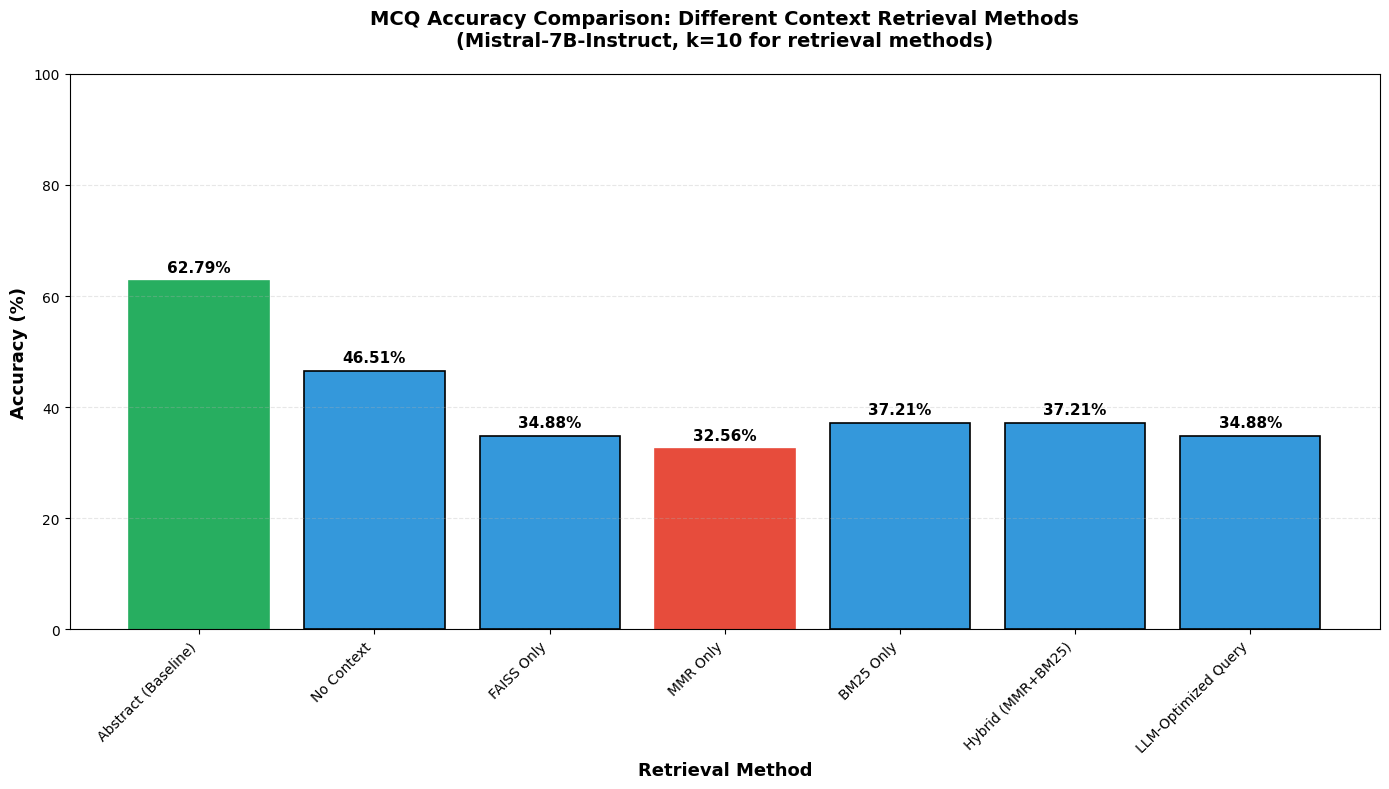

✓ Comparison chart saved!


In [19]:
# Create bar chart comparison
plt.figure(figsize=(14, 8))
methods = list(comparison_results.keys())
accuracies = list(comparison_results.values())

# Create bars with different colors
colors = ['#2ecc71' if method == 'Abstract (Baseline)' else '#3498db' for method in methods]
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.2)

# Highlight best and worst
best_idx = accuracies.index(max(accuracies))
worst_idx = accuracies.index(min(accuracies))
bars[best_idx].set_color('#27ae60')
bars[worst_idx].set_color('#e74c3c')

# Add value labels on bars
for i, (method, acc) in enumerate(zip(methods, accuracies)):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Retrieval Method', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
plt.title('MCQ Accuracy Comparison: Different Context Retrieval Methods\n(Mistral-7B-Instruct, k=10 for retrieval methods)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'accuracy_comparison_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison chart saved!")

In [20]:
# Save comprehensive JSON results
comprehensive_results = {
    'metadata': {
        'model': 'mistralai/Mistral-7B-Instruct-v0.1',
        'test_set': 'QuestionBank31Oct_Ericonly.xlsx - Manually verified sheets only',
        'sheets': ['Synthesis', 'Chem Con & Catalysis'],
        'questions_per_sheet': {sheet: len(synthesis_df[synthesis_df['source_sheet'] == sheet]) 
                                for sheet in synthesis_df['source_sheet'].unique()},
        'total_questions': len(synthesis_df),
        'retrieval_k': 10,
        'timestamp': datetime.now().strftime('%Y%m%d_%H%M%S')
    },
    'accuracy_summary': comparison_results,
    'detailed_results': {
        'abstract_baseline': results,
        'no_context': results_no_context,
        'faiss_only': results_faiss,
        'mmr_only': results_mmr,
        'bm25_only': results_bm25,
        'hybrid': results_hybrid,
        'llm_optimized_query': results_optimized
    }
}

# Save to JSON
output_filename = f"comprehensive_evaluation_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(output_filename, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

print(f"\n✓ Comprehensive results saved to: {output_filename}")
print(f"  - Summary statistics")
print(f"  - Detailed results for all {len(synthesis_df)} questions across all 7 methods")
print(f"  - Optimized queries (for LLM-optimized method)")
print(f"  - Model responses and explanations")


✓ Comprehensive results saved to: comprehensive_evaluation_results_20260216_140319.json
  - Summary statistics
  - Detailed results for all 43 questions across all 7 methods
  - Optimized queries (for LLM-optimized method)
  - Model responses and explanations
